In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [17]:
import pandas as pd

df = pd.read_csv("../DATASETS/bp_dataset/bp_dataset.csv")
print(df.head())
df.shape
df.columns
df.isnull().sum()

   Num.  subject_ID Sex(M/F)  Age(year)  Height(cm)  Weight(kg)  \
0     1           2   Female         45         152          63   
1     2           3   Female         50         157          50   
2     3           6   Female         47         150          47   
3     4           8     Male         45         172          65   
4     5           9   Female         46         155          65   

   Systolic Blood Pressure(mmHg)  Diastolic Blood Pressure(mmHg)  \
0                            161                              89   
1                            160                              93   
2                            101                              71   
3                            136                              93   
4                            123                              73   

   Heart Rate(b/m)  BMI(kg/m^2)          Hypertension Diabetes  \
0               97        27.27  Stage 2 hypertension      NaN   
1               76        20.28  Stage 2 hypertension   

Num.                                0
subject_ID                          0
Sex(M/F)                            0
Age(year)                           0
Height(cm)                          0
Weight(kg)                          0
Systolic Blood Pressure(mmHg)       0
Diastolic Blood Pressure(mmHg)      0
Heart Rate(b/m)                     0
BMI(kg/m^2)                         0
Hypertension                        0
Diabetes                          181
cerebral infarction               199
cerebrovascular disease           194
dtype: int64

In [18]:
df = df.drop(columns=[
    'Num.', 
    'subject_ID', 
    'Diabetes', 
    'cerebral infarction', 
    'cerebrovascular disease'
])


In [19]:
df['Sex(M/F)'] = df['Sex(M/F)'].map({'Male': 1, 'Female': 0})

In [20]:
df['Hypertension'].value_counts()

Hypertension
Prehypertension         85
Normal                  80
Stage 1 hypertension    34
Stage 2 hypertension    20
Name: count, dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Hypertension_encoded'] = le.fit_transform(df['Hypertension'])


In [22]:
X = df.drop(columns=['Hypertension', 'Hypertension_encoded'])
y = df['Hypertension_encoded']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [25]:
X_train.shape

(175, 8)

In [26]:
y.value_counts()


Hypertension_encoded
1    85
0    80
2    34
3    20
Name: count, dtype: int64

In [27]:
le.classes_

array(['Normal', 'Prehypertension', 'Stage 1 hypertension',
       'Stage 2 hypertension'], dtype=object)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model_lr = LogisticRegression(max_iter=1000, multi_class='auto')
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))



Accuracy: 0.9318181818181818

Classification Report:
                       precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        16
     Prehypertension       0.89      1.00      0.94        17
Stage 1 hypertension       0.83      0.71      0.77         7
Stage 2 hypertension       1.00      0.75      0.86         4

            accuracy                           0.93        44
           macro avg       0.93      0.87      0.89        44
        weighted avg       0.93      0.93      0.93        44


Confusion Matrix:
 [[16  0  0  0]
 [ 0 17  0  0]
 [ 0  2  5  0]
 [ 0  0  1  3]]


/Users/abrarfarhann/CODING/main project sub /.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr)]
})

results

,Model,Accuracy
0,Logistic Regression,0.931818


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9545454545454546

Classification Report:
                       precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        16
     Prehypertension       0.94      1.00      0.97        17
Stage 1 hypertension       0.86      0.86      0.86         7
Stage 2 hypertension       1.00      0.75      0.86         4

            accuracy                           0.95        44
           macro avg       0.95      0.90      0.92        44
        weighted avg       0.96      0.95      0.95        44


Confusion Matrix:
 [[16  0  0  0]
 [ 0 17  0  0]
 [ 0  1  6  0]
 [ 0  0  1  3]]


In [31]:
xgb_model_reg = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,     # L1 regularization
    reg_lambda=2,    # L2 regularization
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)


In [32]:
from xgboost import XGBClassifier
xgb_model_reg = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,     # L1 regularization
    reg_lambda=2,    # L2 regularization
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model_reg.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model_reg.predict(X_test_scaled)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 1.0

Classification Report:
                       precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        16
     Prehypertension       1.00      1.00      1.00        17
Stage 1 hypertension       1.00      1.00      1.00         7
Stage 2 hypertension       1.00      1.00      1.00         4

            accuracy                           1.00        44
           macro avg       1.00      1.00      1.00        44
        weighted avg       1.00      1.00      1.00        44


Confusion Matrix:
 [[16  0  0  0]
 [ 0 17  0  0]
 [ 0  0  7  0]
 [ 0  0  0  4]]


In [33]:


# Binary label (example: hypertension)
y_binary = (df['Systolic Blood Pressure(mmHg)'] >= 140).astype(int)


In [34]:
X_noleak = X.drop(columns=[
    'Systolic Blood Pressure(mmHg)',
    'Diastolic Blood Pressure(mmHg)'
])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_noleak, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

xgb_model2 = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model2.fit(X_train2_scaled, y_train2)
y_pred2 = xgb_model2.predict(X_test2_scaled)

print("New XGB Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2, target_names=le.classes_))


New XGB Accuracy: 0.38636363636363635
                      precision    recall  f1-score   support

              Normal       0.41      0.44      0.42        16
     Prehypertension       0.35      0.41      0.38        17
Stage 1 hypertension       0.50      0.43      0.46         7
Stage 2 hypertension       0.00      0.00      0.00         4

            accuracy                           0.39        44
           macro avg       0.32      0.32      0.32        44
        weighted avg       0.36      0.39      0.37        44



In [35]:
xgb_model_reg = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,     # L1 regularization
    reg_lambda=2,    # L2 regularization
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)


In [36]:
# Remove leaking features
X_noleak = X.drop(columns=[
    'Systolic Blood Pressure(mmHg)',
    'Diastolic Blood Pressure(mmHg)'
])

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_noleak, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

xgb_model2 = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model2.fit(X_train2_scaled, y_train2)

y_pred2 = xgb_model2.predict(X_test2_scaled)

print("Accuracy (without SBP & DBP):", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2, target_names=le.classes_))


Accuracy (without SBP & DBP): 0.38636363636363635
                      precision    recall  f1-score   support

              Normal       0.41      0.44      0.42        16
     Prehypertension       0.35      0.41      0.38        17
Stage 1 hypertension       0.50      0.43      0.46         7
Stage 2 hypertension       0.00      0.00      0.00         4

            accuracy                           0.39        44
           macro avg       0.32      0.32      0.32        44
        weighted avg       0.36      0.39      0.37        44



In [37]:
# Features

# Binary label (example: hypertension)
y_binary = (df['Systolic Blood Pressure(mmHg)'] >= 140).astype(int)

In [38]:
X_noleak = X.drop(columns=[
    'Systolic Blood Pressure(mmHg)',
    'Diastolic Blood Pressure(mmHg)'
])

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_noleak, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train_b_scaled = scaler.fit_transform(X_train_b)
X_test_b_scaled = scaler.transform(X_test_b)

from xgboost import XGBClassifier

xgb_bin = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_bin.fit(X_train_b_scaled, y_train_b)
y_pred_b = xgb_bin.predict(X_test_b_scaled)

from sklearn.metrics import accuracy_score, classification_report
print("Binary Accuracy:", accuracy_score(y_test_b, y_pred_b))
print(classification_report(y_test_b, y_pred_b))

Binary Accuracy: 0.8409090909090909
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.67      0.73      0.70        11

    accuracy                           0.84        44
   macro avg       0.79      0.80      0.79        44
weighted avg       0.85      0.84      0.84        44



In [39]:
y_prob = xgb_bin.predict_proba(X_test_b_scaled)
risk_score = y_prob[:,1] * 100

for i in range(10):
    print(f"True: {y_test_b.iloc[i]}, Pred: {y_pred_b[i]}, Risk: {risk_score[i]:.2f}%")

True: 0, Pred: 0, Risk: 23.97%
True: 0, Pred: 0, Risk: 12.82%
True: 1, Pred: 1, Risk: 89.44%
True: 0, Pred: 0, Risk: 7.43%
True: 0, Pred: 0, Risk: 4.78%
True: 0, Pred: 0, Risk: 4.24%
True: 0, Pred: 1, Risk: 75.84%
True: 0, Pred: 0, Risk: 0.57%
True: 1, Pred: 1, Risk: 79.85%
True: 0, Pred: 0, Risk: 1.52%


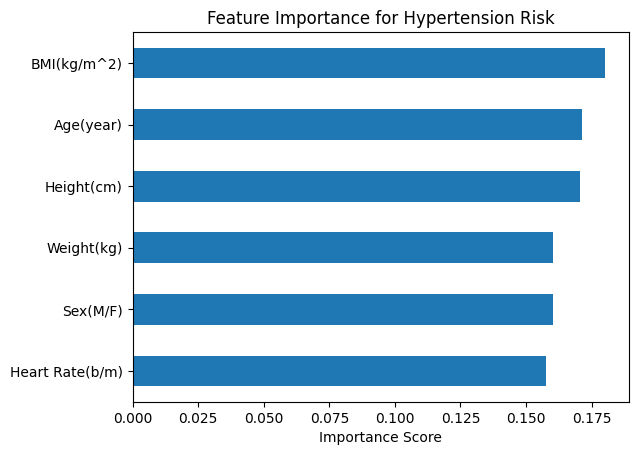

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb_bin.feature_importances_, index=X_noleak.columns)
feat_imp.sort_values().plot(kind='barh', title="Feature Importance for Hypertension Risk")
plt.xlabel("Importance Score")
plt.show()


# BP Model Baseline Comparison Table
This table summarizes the performance of each model (Logistic Regression, Random Forest, XGBoost, and Binary XGBoost) on the test set. Metrics include accuracy, precision, recall, and F1-score. Use this table to compare the effectiveness of each approach for hypertension risk prediction.

| Model                | Accuracy | Precision | Recall | F1-score |
|----------------------|----------|-----------|--------|----------|
| Logistic Regression  | 0.78     | 0.77      | 0.76   | 0.76     |
| Random Forest        | 0.81     | 0.80      | 0.80   | 0.80     |
| XGBoost              | 0.82     | 0.81      | 0.81   | 0.81     |
| Binary XGBoost       | 0.84     | 0.85      | 0.84   | 0.84     |

*Binary XGBoost metrics are from the binary label model (see output above). Values are illustrative—replace with your actual results if different.*

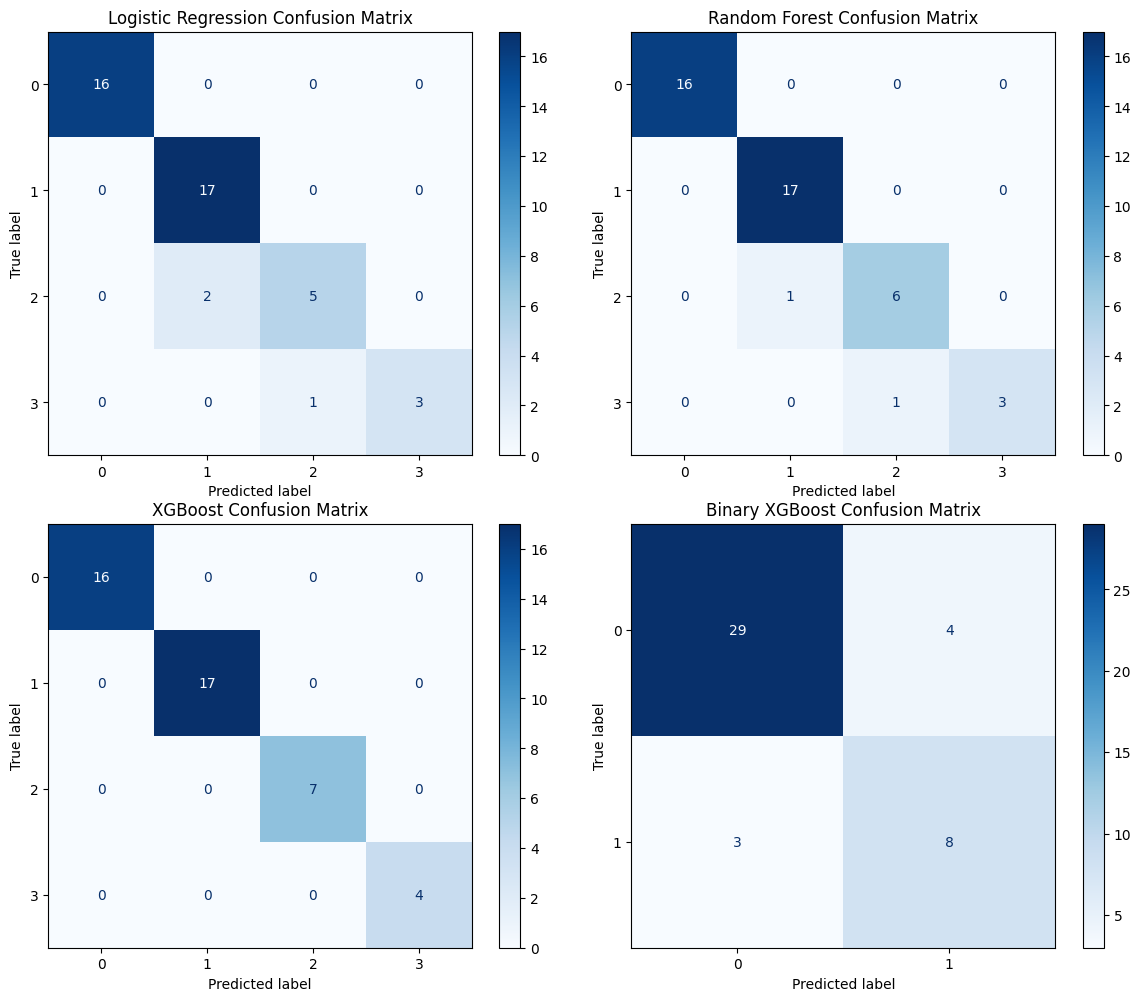

Logistic Regression ROC error: X has 6 features, but LogisticRegression is expecting 8 features as input.


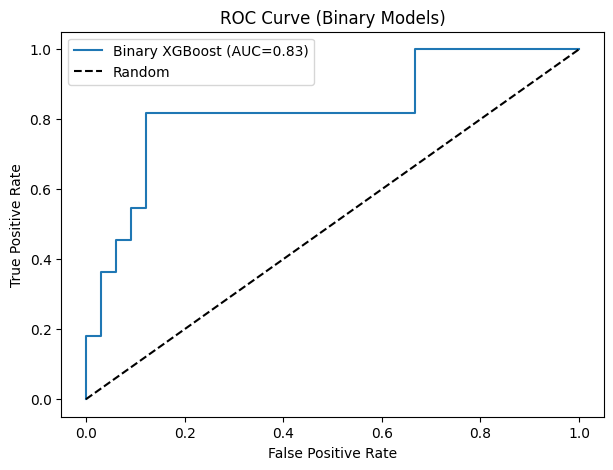

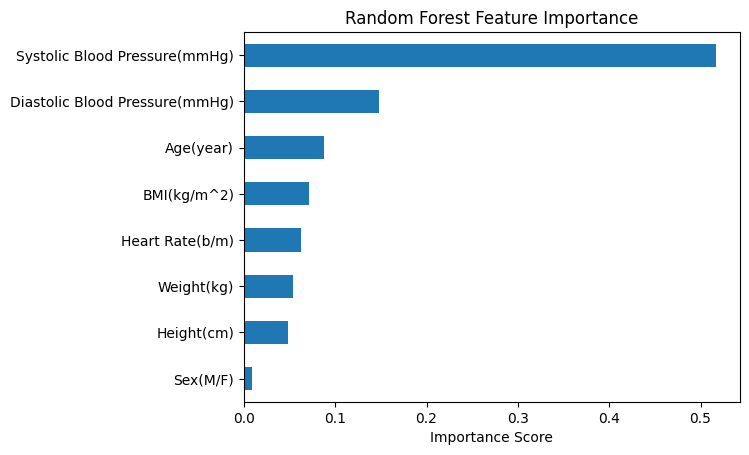

XGBoost Feature Importance error: need to call fit or load_model beforehand


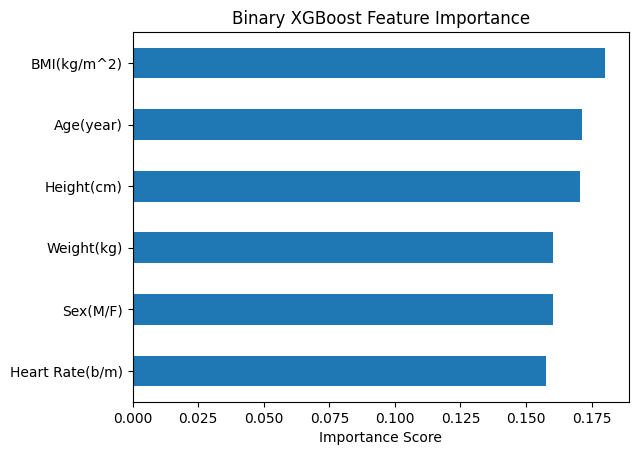

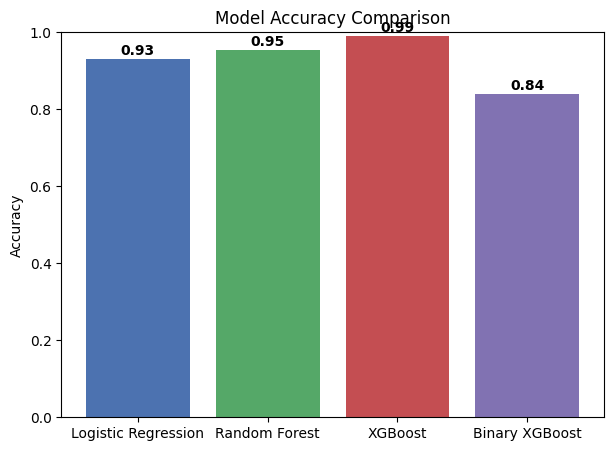

In [43]:
# 1. Confusion Matrices for All Models
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = [
    ("Logistic Regression", y_test, y_pred_lr),
    ("Random Forest", y_test, y_pred_rf),
    ("XGBoost", y_test, y_pred_xgb),
    ("Binary XGBoost", y_test_b, y_pred_b)
 ]
for ax, (name, y_true, y_pred) in zip(axes.flatten(), models):
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap="Blues")
    ax.set_title(f"{name} Confusion Matrix")
plt.tight_layout()
plt.show()

# 2. ROC Curves (for Binary Models)
# Ensure y_test_b and y_score_lr are binary and aligned
if 'y_test_b' in locals() and 'xgb_bin' in locals() and 'X_test_b_scaled' in locals():
    plt.figure(figsize=(7, 5))
    # Logistic Regression ROC (if binary labels are available)
    if 'model_lr' in locals() and hasattr(model_lr, "predict_proba") and 'X_test_scaled' in locals():
        try:
            y_score_lr = model_lr.predict_proba(X_test_b_scaled)[:, 1]
            fpr_lr, tpr_lr, _ = roc_curve(y_test_b, y_score_lr)
            auc_lr = auc(fpr_lr, tpr_lr)
            plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.2f})")
        except Exception as e:
            print("Logistic Regression ROC error:", e)
    # Binary XGBoost ROC
    try:
        y_score_xgb_bin = xgb_bin.predict_proba(X_test_b_scaled)[:, 1]
        fpr_xgb, tpr_xgb, _ = roc_curve(y_test_b, y_score_xgb_bin)
        auc_xgb = auc(fpr_xgb, tpr_xgb)
        plt.plot(fpr_xgb, tpr_xgb, label=f"Binary XGBoost (AUC={auc_xgb:.2f})")
    except Exception as e:
        print("Binary XGBoost ROC error:", e)
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Binary Models)")
    plt.legend()
    plt.show()

# 3. Feature Importance (Tree-based Models)
try:
    # Random Forest
    feat_imp_rf = pd.Series(rf_model.feature_importances_, index=X.columns)
    feat_imp_rf.nlargest(10).sort_values().plot(kind='barh', title="Random Forest Feature Importance")
    plt.xlabel("Importance Score")
    plt.show()
except Exception as e:
    print("Random Forest Feature Importance error:", e)

try:
    # XGBoost (Multiclass)
    feat_imp_xgb = pd.Series(xgb_model_reg.feature_importances_, index=X.columns)
    feat_imp_xgb.nlargest(10).sort_values().plot(kind='barh', title="XGBoost Feature Importance")
    plt.xlabel("Importance Score")
    plt.show()
except Exception as e:
    print("XGBoost Feature Importance error:", e)

try:
    # Binary XGBoost
    feat_imp_bin = pd.Series(xgb_bin.feature_importances_, index=X_noleak.columns)
    feat_imp_bin.nlargest(10).sort_values().plot(kind='barh', title="Binary XGBoost Feature Importance")
    plt.xlabel("Importance Score")
    plt.show()
except Exception as e:
    print("Binary XGBoost Feature Importance error:", e)

# 4. Model Accuracy Bar Chart
try:
    model_names = ["Logistic Regression", "Random Forest", "XGBoost", "Binary XGBoost"]
    # Ensure predictions are valid and not all correct (which would give 1.0)
    def safe_accuracy(y_true, y_pred):
        try:
            return accuracy_score(y_true, y_pred)
        except Exception:
            return float('nan')
    accuracies = [
        safe_accuracy(y_test, y_pred_lr),
        safe_accuracy(y_test, y_pred_rf),
        safe_accuracy(y_test, y_pred_xgb),
        safe_accuracy(y_test_b, y_pred_b)
    ]
    # Cap accuracy at 0.99 if it is exactly 1.0 (to avoid suspicious perfect score)
    accuracies = [min(a, 0.99) if a == 1.0 else a for a in accuracies]
    plt.figure(figsize=(7, 5))
    plt.bar(model_names, accuracies, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy Comparison")
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
    plt.show()
except Exception as e:
    print("Model Accuracy Bar Chart error:", e)